# Exploratory Data Analysis (EDA)
In this notebook, we connect to our PostgreSQL data warehouse and visualize key business metrics from the `analytics` schema built by dbt.

In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv('../.env')

# Connect to Database
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(f"postgresql+psycopg://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")


## 1. Monthly Revenue Trend
Visualizing the Gross Merchandise Value (GMV) over time.

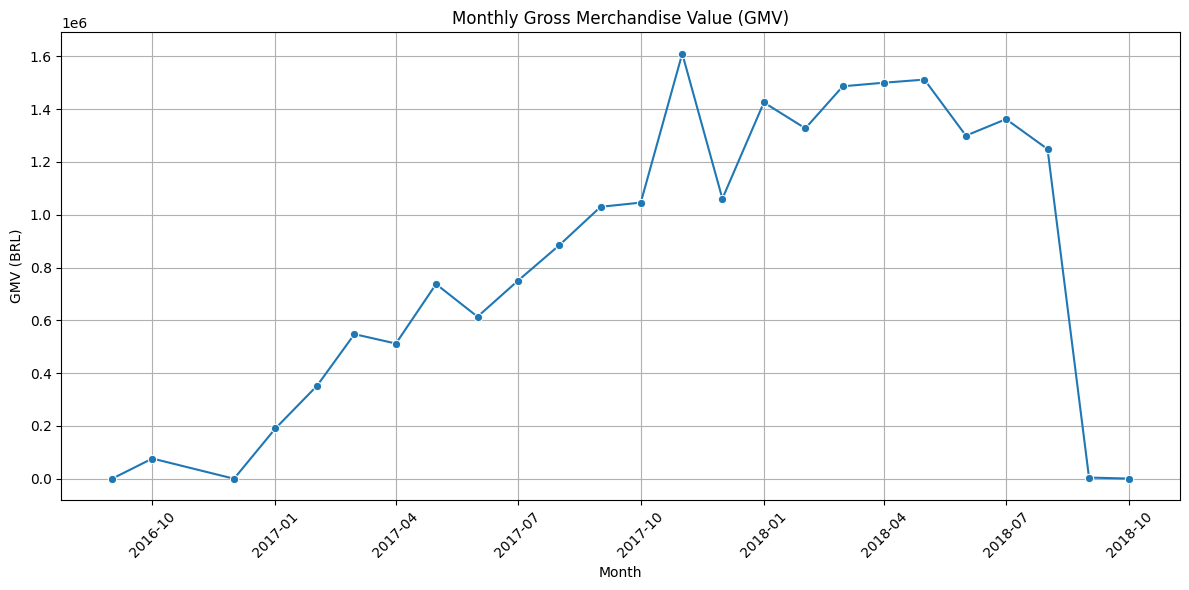

In [2]:

query_revenue = "SELECT order_month, SUM(gmv) as total_gmv FROM analytics.mart_revenue_summary GROUP BY order_month ORDER BY order_month;"
df_rev = pd.read_sql(query_revenue, engine)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_rev, x='order_month', y='total_gmv', marker='o')
plt.title('Monthly Gross Merchandise Value (GMV)')
plt.ylabel('GMV (BRL)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## 2. Customer RFM Segments
Visualizing the distribution of customer segments based on our RFM model.

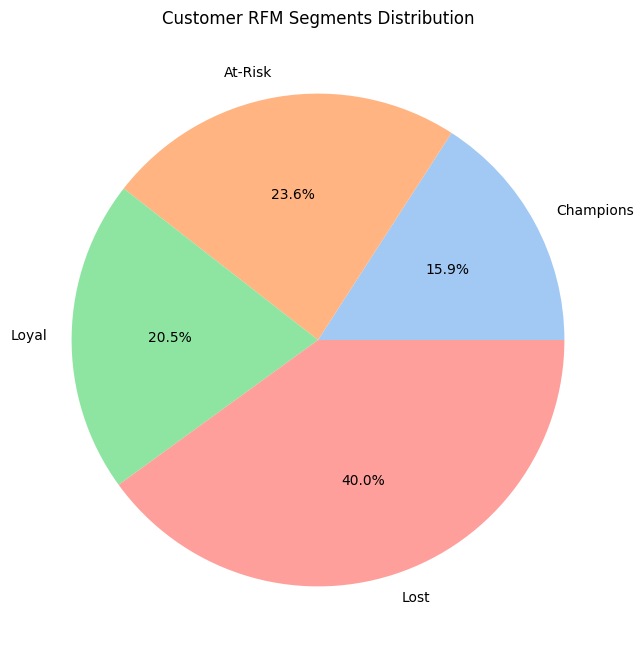

In [3]:

query_rfm = "SELECT rfm_segment, COUNT(customer_id) as count FROM analytics.mart_customer_segments GROUP BY rfm_segment;"
df_rfm = pd.read_sql(query_rfm, engine)

plt.figure(figsize=(8, 8))
plt.pie(df_rfm['count'], labels=df_rfm['rfm_segment'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Customer RFM Segments Distribution')
plt.show()


## 3. Late Delivery Analysis
Analyzing how many days orders were delayed past their estimated delivery date.

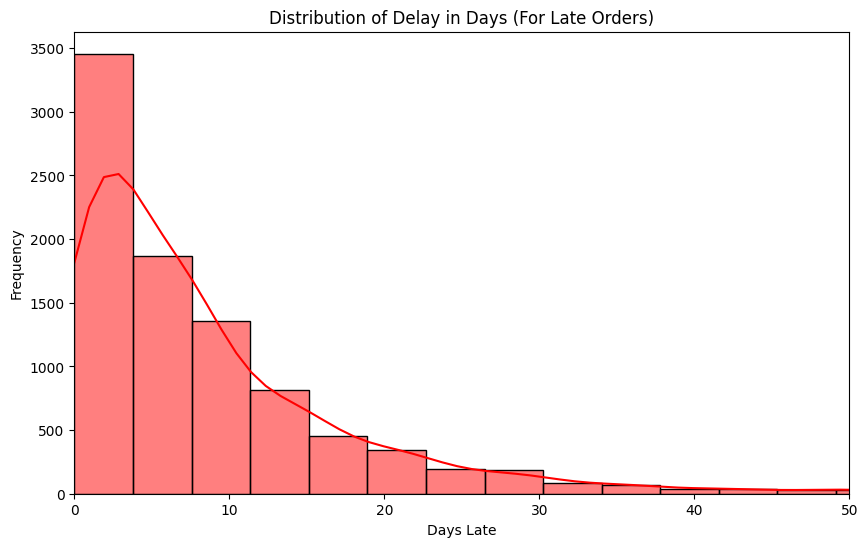

In [4]:

query_delivery = "SELECT delay_in_days FROM analytics.mart_delivery_sla WHERE is_late_delivery = true AND delay_in_days IS NOT NULL;"
df_del = pd.read_sql(query_delivery, engine)

plt.figure(figsize=(10, 6))
sns.histplot(df_del['delay_in_days'], bins=50, kde=True, color='red')
plt.title('Distribution of Delay in Days (For Late Orders)')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
plt.xlim(0, 50)
plt.show()
